In [12]:
# 3.i / 3.ii (Lexicons studied/used in code: VADER + TextBlob)
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('vader_lexicon')
# 3.i (VADER)
from nltk.sentiment import SentimentIntensityAnalyzer
# 3.ii (TextBlob)
from textblob import TextBlob
# 7 (accuracy/precision/recall/F1 + confusion matrix)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\barre\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [13]:
# 10.
# =========================
# CONFIG (AMAZON_FASHION_5.json.gz)
# =========================

DATASET_PATH = "AMAZON_FASHION_5.json.gz"

OUTPUT_DIR = "phase1_outputs"

RANDOM_SEED = 42
SAMPLE_SIZE = 1000

# When True the notebook will both save and display figures during execution.
SHOW_PLOTS = True

In [14]:
# =========================
# UTILS
# =========================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

In [15]:
# 10 (submit documented code: load and normalize required dataset)
def load_reviews_dataset(path: str) -> pd.DataFrame:
    """
    Loads the AMAZON_FASHION_5 review file and normalizes key columns so the
    rest of the Phase 1 workflow can stay close to the original notebook.
    """
    df = pd.read_json(path, lines=True, compression="gzip")
    df = df.rename(
        columns={
            "overall": "ratings",
            "reviewText": "review_text",
            "reviewerID": "reviewer_id",
        }
    )
    return df.copy()

In [16]:
# 2.b (choose the appropriate columns for the sentiment analyzer)
def to_text_maybe_list(x) -> str:
    """
    Some datasets store tokens like: "['good','shirt']" as a string.
    Convert that into: "good shirt".
    """
    if pd.isna(x):
        return ""

    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            lst = ast.literal_eval(s)
            if isinstance(lst, list):
                return " ".join(str(t) for t in lst).strip()
        except Exception:
            pass

    return s

In [17]:
# 2.b (combine chosen text columns into one sentiment input)
def combine_summary_review(summary_text: str, review_text: str) -> str:
    summary_text = (summary_text or "").strip()
    review_text = (review_text or "").strip()
    if summary_text and review_text:
        return f"{summary_text}. {review_text}"
    return summary_text or review_text

In [18]:
# 2.a (label data based on the rating of the product)
def label_from_rating(r):
    """
    Label rules required by the Phase 1 rubric.
    """
    try:
        r = float(r)
    except Exception:
        return np.nan

    # 2.a.i. (Ratings 4,5 => Positive)
    if r >= 4:
        return "Positive"
    # 2.a.ii. (Rating 3 => Neutral)
    elif r == 3:
        return "Neutral"
    # 2.a.iii. (Ratings 1,2 => Negative)
    elif r <= 2:
        return "Negative"
    return np.nan

In [19]:
# 4 (VADER preprocessing based on the selected lexicon characteristics)
def preprocess_for_vader(text: str) -> str:
    # 4 (keep punctuation/emphasis, only remove URLs and normalize spaces)
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [20]:
# 4 (TextBlob preprocessing based on the selected lexicon characteristics)
def preprocess_for_textblob(text: str) -> str:
    # 4 (normalize lowercase text, remove URLs, and remove most non-letters)
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [21]:
# 1.a / 1.b / 1.e (plots used for dataset exploration)
def save_hist(values, title, xlabel, filename, bins=50):
    plt.figure()
    plt.hist(pd.Series(values).dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

In [22]:
# 1.c / 1.d / 1.e (boxplots used for dataset exploration)
def save_boxplot(values, title, ylabel, filename):
    plt.figure()
    plt.boxplot(pd.Series(values).dropna(), vert=True)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

In [23]:
# 7 (confusion matrix outputs for validation)
def save_confusion(cm, labels, title, filename):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=30)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

In [24]:
# 7 (accuracy/precision/recall/F1 + confusion matrix)
def evaluate(y_true, y_pred, labels=("Negative", "Neutral", "Positive")):
    acc = accuracy_score(y_true, y_pred)
    pr_w, rc_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(labels), average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))
    return acc, pr_w, rc_w, f1_w, cm

In [25]:
# =========================
# MODELS (Lexicon)
# =========================
# 6.a / 3.i (VADER lexicon model)
def vader_predict(texts: pd.Series) -> pd.Series:
    analyzer = SentimentIntensityAnalyzer()
    preds = []
    for t in texts:
        c = analyzer.polarity_scores(t)["compound"]
        if c >= 0.05:
            preds.append("Positive")
        elif c <= -0.05:
            preds.append("Negative")
        else:
            preds.append("Neutral")
    return pd.Series(preds, index=texts.index)

In [26]:
# 6.a / 3.ii (TextBlob lexicon model)
def textblob_predict(texts: pd.Series) -> pd.Series:
    preds = []
    for t in texts:
        pol = TextBlob(t).sentiment.polarity
        if pol > 0.1:
            preds.append("Positive")
        elif pol < -0.1:
            preds.append("Negative")
        else:
            preds.append("Neutral")
    return pd.Series(preds, index=texts.index)

In [27]:
# =========================
# MAIN
# =========================

# Setup output directory
# 10 (submit documented code)
ensure_dir(OUTPUT_DIR)

In [28]:
# -------------------------
# Load AMAZON_FASHION_5.json.gz
# -------------------------
# 10 (submit documented code)
df_train = load_reviews_dataset(DATASET_PATH)

print("Dataset shape:", df_train.shape)
print("Available columns:", sorted(df_train.columns))

Dataset shape: (3176, 12)
Available columns: ['asin', 'image', 'ratings', 'reviewTime', 'review_text', 'reviewerName', 'reviewer_id', 'style', 'summary', 'unixReviewTime', 'verified', 'vote']


## Phase 1 Dataset Choice
This notebook now uses only `AMAZON_FASHION_5.json.gz`, which is the required Phase 1 source file.
The code normalizes the dataset schema once after loading so the rest of the analysis can stay close to the original workflow.

Rows before rating cleanup: 3176
Rows after rating cleanup : 3176
Average rating: 4.404
Median rating : 5.0
Unique users  : 406
Unique products: 31
Missing review_text rows: 16


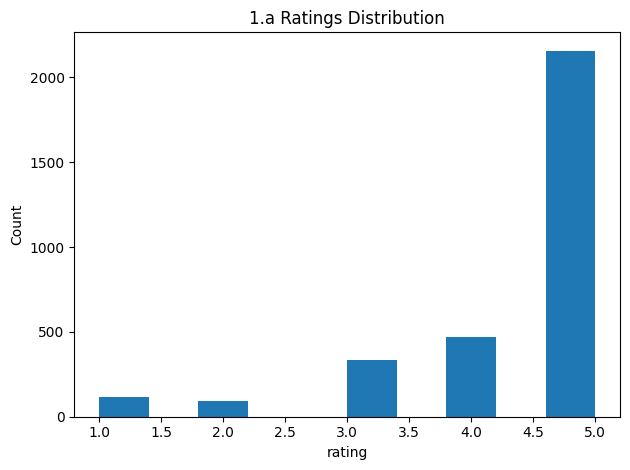

In [29]:
# -------------------------
# Dataset data exploration
# -------------------------
# 1.a (counts and averages)
df_train["ratings"] = pd.to_numeric(df_train["ratings"], errors="coerce")
n_before = len(df_train)
df_train = df_train.dropna(subset=["ratings"]).copy()
n_after = len(df_train)

avg_rating = df_train["ratings"].mean()
med_rating = df_train["ratings"].median()
n_users = df_train["reviewer_id"].nunique() if "reviewer_id" in df_train.columns else None
n_products = df_train["asin"].nunique() if "asin" in df_train.columns else None
missing_review_text = int(df_train["review_text"].isna().sum()) if "review_text" in df_train.columns else None

print("Rows before rating cleanup:", n_before)
print("Rows after rating cleanup :", n_after)
print("Average rating:", round(avg_rating, 3))
print("Median rating :", med_rating)
print("Unique users  :", n_users)
print("Unique products:", n_products)
print("Missing review_text rows:", missing_review_text)

save_hist(df_train["ratings"], "1.a Ratings Distribution", "rating", "1a_ratings_hist.png", bins=10)

Products with at least one review: 31
Average reviews per product: 102.452


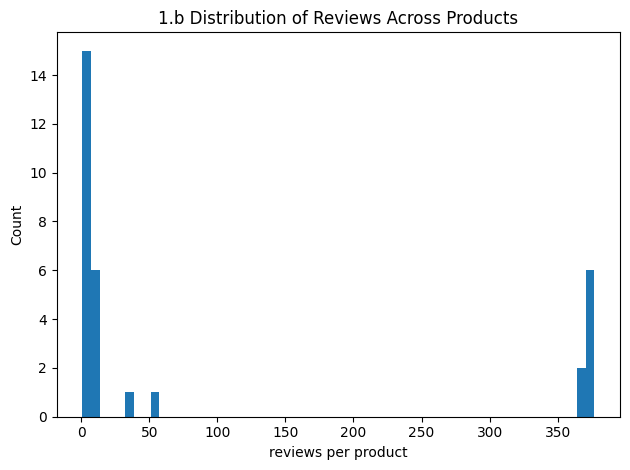

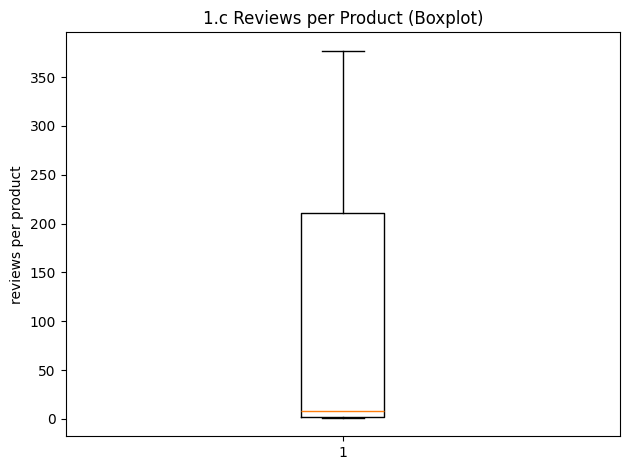

Users with at least one review: 406
Average reviews per user: 7.823


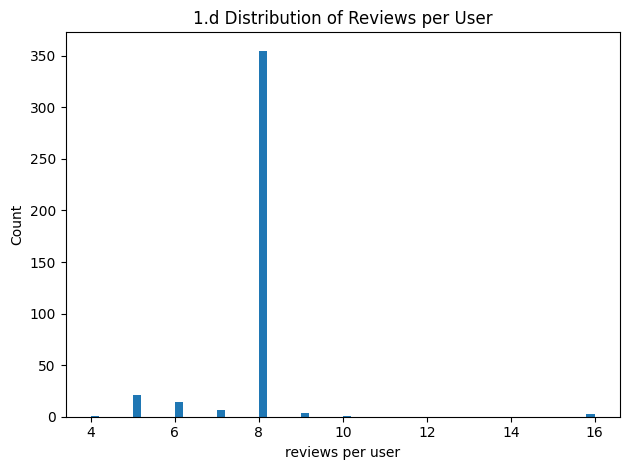

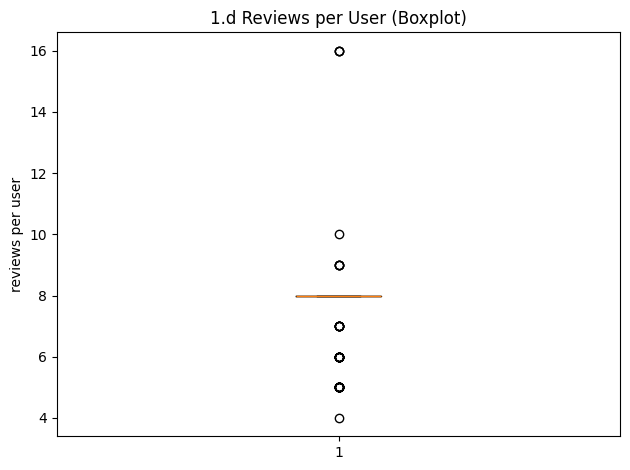

In [30]:
# Reviews per product / user

if "asin" in df_train.columns:
    # 1.b.
    reviews_per_product = df_train["asin"].value_counts()
    print("Products with at least one review:", len(reviews_per_product))
    print("Average reviews per product:", round(reviews_per_product.mean(), 3))
    save_hist(
        reviews_per_product.values,
        "1.b Distribution of Reviews Across Products",
        "reviews per product",
        "1b_reviews_across_products_hist.png",
        bins=60
    )
    # 1.c.
    save_boxplot(
        reviews_per_product.values,
        "1.c Reviews per Product (Boxplot)",
        "reviews per product",
        "1c_reviews_per_product_boxplot.png"
    )

if "reviewer_id" in df_train.columns:
    # 1.d.
    reviews_per_user = df_train["reviewer_id"].value_counts()
    print("Users with at least one review:", len(reviews_per_user))
    print("Average reviews per user:", round(reviews_per_user.mean(), 3))
    save_hist(
        reviews_per_user.values,
        "1.d Distribution of Reviews per User",
        "reviews per user",
        "1d_reviews_per_user_hist.png",
        bins=60
    )
    save_boxplot(
        reviews_per_user.values,
        "1.d Reviews per User (Boxplot)",
        "reviews per user",
        "1d_reviews_per_user_boxplot.png"
    )

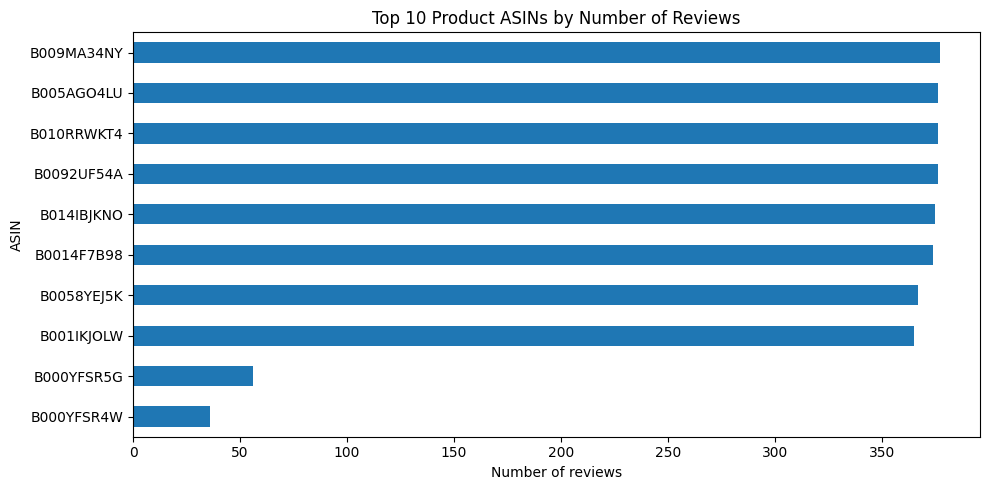

Product ASIN with the most reviews: B009MA34NY
Number of reviews for that product ASIN: 377


In [31]:
# 1.b / 1.c (identify which product ASIN has the most reviews)
if "asin" in df_train.columns:
    top_reviewed_products = df_train["asin"].value_counts().head(10)
    most_reviewed_asin = top_reviewed_products.index[0]
    most_reviewed_count = int(top_reviewed_products.iloc[0])

    plt.figure(figsize=(10, 5))
    top_reviewed_products.sort_values().plot(kind="barh")
    plt.title("Top 10 Product ASINs by Number of Reviews")
    plt.xlabel("Number of reviews")
    plt.ylabel("ASIN")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "1b_top_reviewed_products.png"))
    if SHOW_PLOTS:
        plt.show()
    plt.close()

    print("Product ASIN with the most reviews:", most_reviewed_asin)
    print("Number of reviews for that product ASIN:", most_reviewed_count)

In [32]:
# 1.d. / 1.g. (check whether reviews are coming from the same user)
reviewer_counts = df_train["reviewer_id"].value_counts()
users_with_multiple_reviews = int((reviewer_counts > 1).sum())
repeated_user_product_pairs = int(df_train.duplicated(subset=["reviewer_id", "asin"]).sum())

print("Number of unique users:", int(df_train["reviewer_id"].nunique()))
print("Number of users with multiple reviews:", users_with_multiple_reviews)
print("Number of repeated reviewer_id + asin pairs:", repeated_user_product_pairs)

if repeated_user_product_pairs > 0:
    print("Conclusion: the dataset includes repeated user-product review pairs, so repeat-user behavior should be noted in the Phase 1 report.")
else:
    print("Conclusion: the dataset does not show repeated user-product review pairs in this Phase 1 check.")


Number of unique users: 406
Number of users with multiple reviews: 406
Number of repeated reviewer_id + asin pairs: 134
Conclusion: the dataset includes repeated user-product review pairs, so repeat-user behavior should be noted in the Phase 1 report.


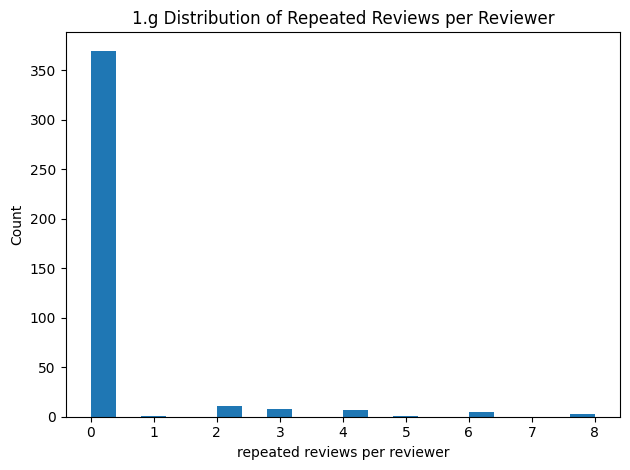

Histogram saved: 1g_repeated_reviews_per_reviewer_hist.png


In [33]:
# 1.g histogram visualization for repeated reviewer-product behavior
df_pairs = df_train.groupby("reviewer_id").agg(
    total_reviews=("asin", "count"),
    unique_products=("asin", "nunique")
).reset_index()
df_pairs["repeated_reviews"] = df_pairs["total_reviews"] - df_pairs["unique_products"]

save_hist(
    df_pairs["repeated_reviews"].values,
    "1.g Distribution of Repeated Reviews per Reviewer",
    "repeated reviews per reviewer",
    "1g_repeated_reviews_per_reviewer_hist.png",
    bins=20
)

print("Histogram saved: 1g_repeated_reviews_per_reviewer_hist.png")

Review-text word-length outliers: 163
IQR lower bound: -37.0
IQR upper bound: 75.0


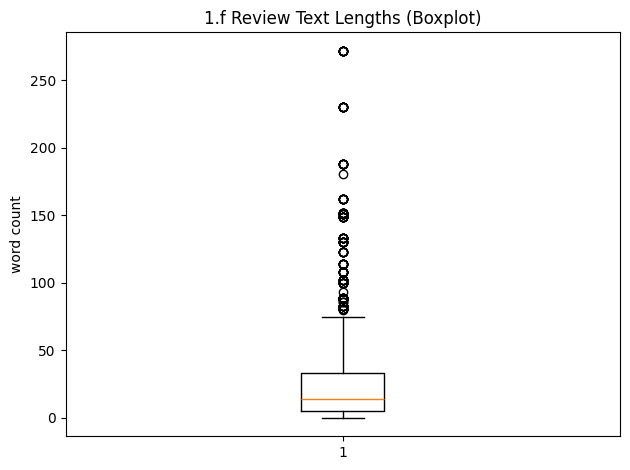

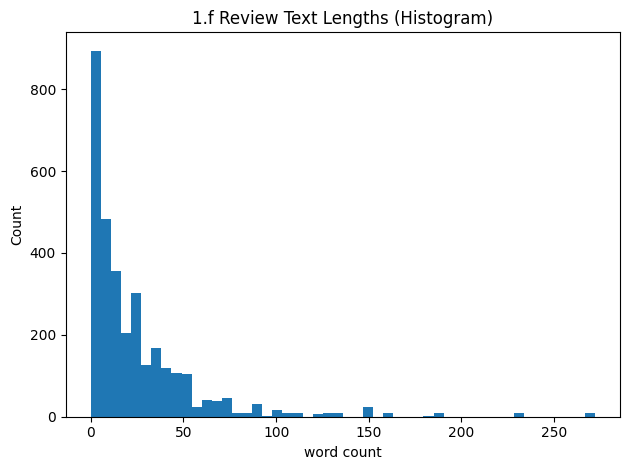

In [34]:
# Outlier detection (IQR)
# 2.c (check for outliers)
if "review_text_str" not in df_train.columns:
    df_train["review_text_str"] = df_train["review_text"].apply(to_text_maybe_list)

if "summary_str" not in df_train.columns:
    df_train["summary_str"] = df_train["summary"].apply(to_text_maybe_list)

if "review_len_words" not in df_train.columns or "review_len_chars" not in df_train.columns:
    df_train["review_len_words"] = df_train["review_text_str"].apply(lambda x: len(str(x).split()))
    df_train["review_len_chars"] = df_train["review_text_str"].apply(lambda x: len(str(x)))

q1 = df_train["review_len_words"].quantile(0.25)
q3 = df_train["review_len_words"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (df_train["review_len_words"] < lower) | (df_train["review_len_words"] > upper)
outlier_count = int(outlier_mask.sum())

# 1.f (analyze lengths)
print("Review-text word-length outliers:", outlier_count)
print("IQR lower bound:", round(lower, 3))
print("IQR upper bound:", round(upper, 3))

# Save plots for review lengths
save_boxplot(df_train["review_len_words"], "1.f Review Text Lengths (Boxplot)", "word count", "1f_review_length_boxplot.png")
save_hist(df_train["review_len_words"], "1.f Review Text Lengths (Histogram)", "word count", "1f_review_length_hist.png", bins=50)

df_train.loc[outlier_mask, ["ratings", "review_len_words", "review_len_chars", "review_text_str", "summary_str"]] \
    .head(15) \
    .to_csv(os.path.join(OUTPUT_DIR, "1f_review_length_outlier_examples.csv"), index=False)


## Text Columns Chosen
For sentiment analysis, the notebook uses `summary` and `reviewText` together.
`summary` captures the short headline sentiment, while `reviewText` carries the detailed opinion. Combining them preserves more sentiment signal than using either field alone.

In [35]:
# 1.g. (check for duplicates)
if "review_text_str" not in df_train.columns:
    df_train["review_text_str"] = df_train["review_text"].apply(to_text_maybe_list)

if "summary_str" not in df_train.columns:
    df_train["summary_str"] = df_train["summary"].apply(to_text_maybe_list)

if "full_text" not in df_train.columns:
    df_train["full_text"] = df_train.apply(
        lambda r: combine_summary_review(r["summary_str"], r["review_text_str"]),
        axis=1
    )
    df_train["full_text"] = df_train["full_text"].fillna("").astype(str)

dup_full_text = df_train.duplicated(subset=["full_text"]).sum()
dup_summary_review = df_train.duplicated(subset=["summary_str", "review_text_str"]).sum()

print("Duplicate full_text:", dup_full_text)
print("Duplicate summary+review:", dup_summary_review)
print("Duplicate full_text percentage:", round(100 * dup_full_text / len(df_train), 3))

Duplicate full_text: 2733
Duplicate summary+review: 2733
Duplicate full_text percentage: 86.052


In [36]:
# Labeling
# 2.a.i / 2.a.ii / 2.a.iii (apply rating-based sentiment labels)
df_train["label"] = df_train["ratings"].apply(label_from_rating)
df_train = df_train.dropna(subset=["label"]).copy()

print("Label distribution:")
print(df_train["label"].value_counts())

Label distribution:
label
Positive    2629
Neutral      337
Negative     210
Name: count, dtype: int64


In [37]:
# Model-specific preprocessing
# 4 (apply model-specific preprocessing for each selected lexicon)
df_train["text_vader"] = df_train["full_text"].apply(preprocess_for_vader)
df_train["text_blob"]  = df_train["full_text"].apply(preprocess_for_textblob)

## Lexicon And Preprocessing Justification
The notebook keeps VADER and TextBlob as the two Phase 1 lexicon models.
VADER is designed for short opinion-rich text and benefits from punctuation and emphasis, so its preprocessing is intentionally light. TextBlob uses polarity over cleaned text, so the notebook lowercases and removes most non-letter noise before scoring. SentiWordNet was not chosen here because it requires a heavier word-sense pipeline, which is harder to keep consistent for a compact Phase 1 baseline.

In [38]:
# Sampling
# 5 (randomly select 1000 reviews from your dataset)
df_s = df_train.sample(
    n=min(SAMPLE_SIZE, len(df_train)),
    random_state=RANDOM_SEED
).copy()

print("Sample size:", len(df_s))
print("Sample label distribution:")
print(df_s["label"].value_counts())

y_true = df_s["label"].astype(str)

Sample size: 1000
Sample label distribution:
label
Positive    837
Neutral     101
Negative     62
Name: count, dtype: int64


In [39]:
# Predictions
# 6.a (build two lexicon-based sentiment analysis models)
y_vader = vader_predict(df_s["text_vader"])
y_blob  = textblob_predict(df_s["text_blob"])

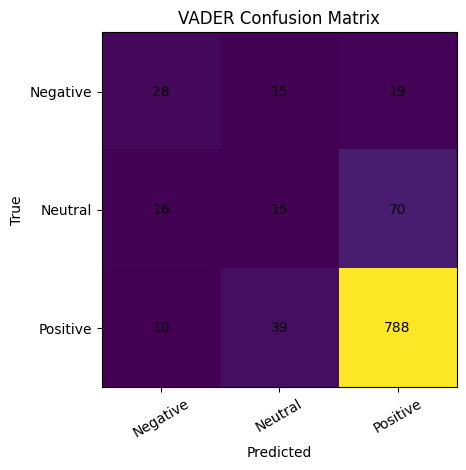

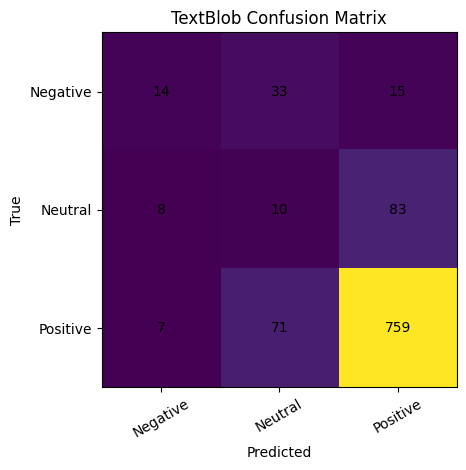

      Model  Accuracy  Precision_w  Recall_w      F1_w
0     VADER     0.831     0.806164     0.831  0.817365
1  TextBlob     0.783     0.780078     0.783  0.778511


In [40]:
# Evaluation
# 7 (accuracy/precision/recall/F1 + confusion matrix)
labels_order = ("Negative", "Neutral", "Positive")

acc_v, pr_v, rc_v, f1_v, cm_v = evaluate(y_true, y_vader, labels=labels_order)
acc_b, pr_b, rc_b, f1_b, cm_b = evaluate(y_true, y_blob, labels=labels_order)

save_confusion(cm_v, labels_order, "VADER Confusion Matrix", "7_cm_vader.png")
save_confusion(cm_b, labels_order, "TextBlob Confusion Matrix", "7_cm_textblob.png")

comparison = pd.DataFrame([
    {"Model": "VADER", "Accuracy": acc_v, "Precision_w": pr_v, "Recall_w": rc_v, "F1_w": f1_v},
    {"Model": "TextBlob", "Accuracy": acc_b, "Precision_w": pr_b, "Recall_w": rc_b, "F1_w": f1_b},
])
comparison = comparison.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

comparison.to_csv(os.path.join(OUTPUT_DIR, "7_lexicon_comparison_table.csv"), index=False)

print(comparison)

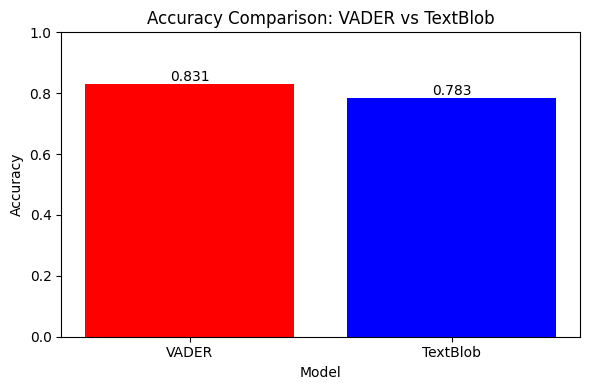

In [41]:
# Accuracy bar chart
plt.figure(figsize=(6, 4))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    color=["red", "blue"]   # VADER = red, TextBlob = blue
)

plt.title("Accuracy Comparison: VADER vs TextBlob")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, round(yval, 3), ha="center")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "7_accuracy_comparison_chart.png"))
if SHOW_PLOTS:
    plt.show()
plt.close()

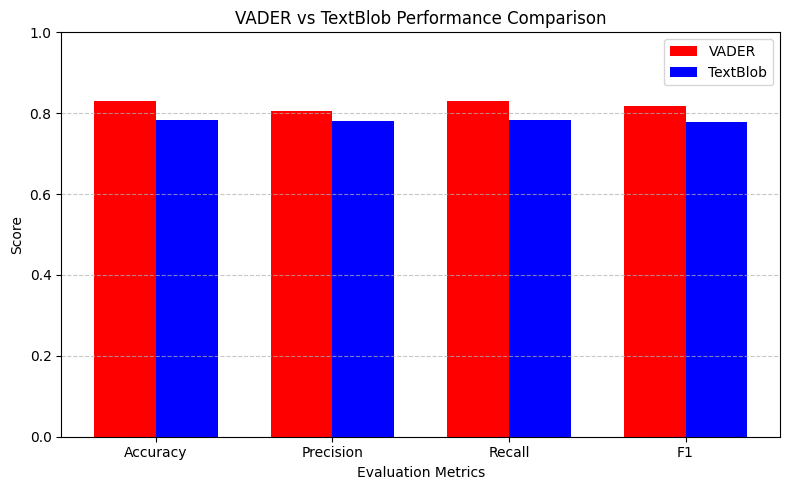

In [42]:
# Metrics comparison (Accuracy / Precision / Recall / F1)
metrics = ["Accuracy", "Precision_w", "Recall_w", "F1_w"]

vader_scores = comparison[comparison["Model"] == "VADER"][metrics].values.flatten()
blob_scores  = comparison[comparison["Model"] == "TextBlob"][metrics].values.flatten()

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, vader_scores, width, label="VADER", color="red")
plt.bar(x + width / 2, blob_scores,  width, label="TextBlob", color="blue")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("VADER vs TextBlob Performance Comparison")
plt.xticks(x, ["Accuracy", "Precision", "Recall", "F1"])
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "7_metric_comparison_chart.png"))
if SHOW_PLOTS:
    plt.show()
plt.close()

## Phase 2: Machine Learning, Comparison, Review Enhancement, and Local LLM Tasks

This section adds only Phase 2 code and comments under the existing Phase 1 notebook content.
All Phase 1 code/comments remain unchanged.

In [43]:
# 11 / 12 / 13 / 14 / 15 / 16 / 17
# Phase 2 setup for outputs and reproducibility (kept separate from Phase 1 config)
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from IPython.display import display

PHASE2_OUTPUT_DIR = "phase2_outputs"
PHASE2_SAMPLE_SIZE = 2500
PHASE2_TEST_SIZE = 0.30
PHASE2_RANDOM_STATE = 42

ensure_dir(PHASE2_OUTPUT_DIR)
print("Phase 2 output folder:", PHASE2_OUTPUT_DIR)

# 11 / 13 / 14 helper: save confusion matrices only to phase2_outputs
def save_confusion_phase2(cm, labels, title, filename):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=30)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(os.path.join(PHASE2_OUTPUT_DIR, filename))
    plt.show()
    plt.close()

Phase 2 output folder: phase2_outputs


In [44]:
# 11.a. Select a subset of minimum 2000 reviews and prepare labels/text
# This cell rebuilds a clean Phase 2 subset (2500 rows) from the original dataset.
phase2_df = load_reviews_dataset(DATASET_PATH).copy()

phase2_df["summary_text"] = phase2_df.get("summary", "").apply(to_text_maybe_list)
phase2_df["review_text_clean"] = phase2_df.get("review_text", "").apply(to_text_maybe_list)
phase2_df["full_text"] = phase2_df.apply(
    lambda row: combine_summary_review(row["summary_text"], row["review_text_clean"]), axis=1
)

phase2_df["ratings"] = pd.to_numeric(phase2_df["ratings"], errors="coerce")
phase2_df["label"] = phase2_df["ratings"].apply(label_from_rating)
phase2_df = phase2_df.dropna(subset=["ratings", "label", "full_text"]).copy()
phase2_df["full_text"] = phase2_df["full_text"].astype(str).str.strip()
phase2_df = phase2_df[phase2_df["full_text"].str.len() > 0].copy()

phase2_subset = phase2_df.sample(n=PHASE2_SAMPLE_SIZE, random_state=PHASE2_RANDOM_STATE).copy()
phase2_subset = phase2_subset.reset_index(drop=True)

print("Phase 2 subset shape:", phase2_subset.shape)
print("Class distribution:\n", phase2_subset["label"].value_counts())

Phase 2 subset shape: (2500, 16)
Class distribution:
 label
Positive    2066
Neutral      260
Negative     174
Name: count, dtype: int64


### 11.b. Data exploration and preprocessing justification

We keep preprocessing simple and in module scope:
- Remove missing/empty records for fair model training.
- Normalize text with lowercase, URL removal, and whitespace cleanup.
- Keep labels from rating rules already used in Phase 1.
- Check class distribution and review length to validate the subset.

In [45]:
# 11.b. Carry out exploration and preprocessing on the subset
# This cell reports subset quality and builds one cleaned text column for ML.
phase2_subset["review_word_count"] = phase2_subset["full_text"].str.split().apply(len)
print("Review length summary:\n", phase2_subset["review_word_count"].describe())
print("Label proportions:\n", phase2_subset["label"].value_counts(normalize=True).round(4))

# 11.b.i. Simple text normalization for ML pipeline input
phase2_subset["ml_text"] = phase2_subset["full_text"].astype(str).str.lower()
phase2_subset["ml_text"] = phase2_subset["ml_text"].str.replace(r"http\S+|www\.\S+", " ", regex=True)
phase2_subset["ml_text"] = phase2_subset["ml_text"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Prepared ML text rows:", len(phase2_subset))

Review length summary:
 count    2500.000000
mean       28.726400
std        33.182634
min         2.000000
25%         7.000000
50%        18.000000
75%        39.000000
max       275.000000
Name: review_word_count, dtype: float64
Label proportions:
 label
Positive    0.8264
Neutral     0.1040
Negative    0.0696
Name: proportion, dtype: float64
Prepared ML text rows: 2500


### 11.c. Text representation choice

We use TF-IDF because it is a suitable and standard module-level representation for sentiment text classification. It converts text to weighted word features, is easy to explain, and works well with Logistic Regression and SVM for this task.

In [46]:
# 11.c. Represent text using TF-IDF
# Fit/transform will happen inside model pipelines to avoid data leakage.
X_all = phase2_subset["ml_text"].copy()
y_all = phase2_subset["label"].copy()

print("TF-IDF representation selected for model pipelines.")

TF-IDF representation selected for model pipelines.


In [47]:
# 11.d. Split data into 70% train and 30% test using stratified label distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=PHASE2_TEST_SIZE,
    random_state=PHASE2_RANDOM_STATE,
    stratify=y_all
)

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train label distribution:\n", y_train.value_counts(normalize=True).round(4))
print("Test label distribution:\n", y_test.value_counts(normalize=True).round(4))

Train size: 1750 Test size: 750
Train label distribution:
 label
Positive    0.8263
Neutral     0.1040
Negative    0.0697
Name: proportion, dtype: float64
Test label distribution:
 label
Positive    0.8267
Neutral     0.1040
Negative    0.0693
Name: proportion, dtype: float64


In [48]:
# 11.e. Build sentiment analysis models using 70% training data (try all listed options)

# 11.e.i. Model 1: Logistic Regression with TF-IDF
start_lr = time.time()
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000, random_state=PHASE2_RANDOM_STATE))
])
lr_pipeline.fit(X_train, y_train)
lr_train_seconds = time.time() - start_lr

# 11.e.ii. Model 2: SVM (LinearSVC) with TF-IDF
start_svm = time.time()
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])
svm_pipeline.fit(X_train, y_train)
svm_train_seconds = time.time() - start_svm

# 11.e.iii. Model 3: Naive Bayes (MultinomialNB) with TF-IDF
start_nb = time.time()
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])
nb_pipeline.fit(X_train, y_train)
nb_train_seconds = time.time() - start_nb

# 11.e.iv. Model 4: Gradient Boosting with TF-IDF
start_gb = time.time()
tfidf_gb = TfidfVectorizer(max_features=2000)
X_train_gb = tfidf_gb.fit_transform(X_train).toarray()
gb_model = GradientBoostingClassifier(random_state=PHASE2_RANDOM_STATE)
gb_model.fit(X_train_gb, y_train)
gb_train_seconds = time.time() - start_gb

# 11.e.v. Model 5: MLP with TF-IDF
start_mlp = time.time()
mlp_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=PHASE2_RANDOM_STATE))
])
mlp_pipeline.fit(X_train, y_train)
mlp_train_seconds = time.time() - start_mlp

In [49]:
# 12. Compute training accuracy for all models

lr_train_acc = lr_pipeline.score(X_train, y_train)
svm_train_acc = svm_pipeline.score(X_train, y_train)
nb_train_acc = nb_pipeline.score(X_train, y_train)

gb_train_acc = gb_model.score(X_train_gb, y_train)
mlp_train_acc = mlp_pipeline.score(X_train, y_train)


# 12. Record training process results (ALL 5 models)
training_summary_df = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "train_rows": len(X_train),
        "train_seconds": round(lr_train_seconds, 3),
        "train_accuracy": round(lr_train_acc, 3)
    },
    {
        "model": "LinearSVC",
        "train_rows": len(X_train),
        "train_seconds": round(svm_train_seconds, 3),
        "train_accuracy": round(svm_train_acc, 3)
    },
    {
        "model": "MultinomialNB",
        "train_rows": len(X_train),
        "train_seconds": round(nb_train_seconds, 3),
        "train_accuracy": round(nb_train_acc, 3)
    },
    {
        "model": "GradientBoosting",
        "train_rows": len(X_train),
        "train_seconds": round(gb_train_seconds, 3),
        "train_accuracy": round(gb_train_acc, 3)
    },
    {
        "model": "MLPClassifier",
        "train_rows": len(X_train),
        "train_seconds": round(mlp_train_seconds, 3),
        "train_accuracy": round(mlp_train_acc, 3)
    }
])

display(training_summary_df)

,model,train_rows,train_seconds,train_accuracy
0,LogisticRegression,1750,0.071,0.992
1,LinearSVC,1750,0.040,1.000
2,MultinomialNB,1750,0.028,0.916
3,GradientBoosting,1750,11.770,1.000
4,MLPClassifier,1750,3.770,1.000


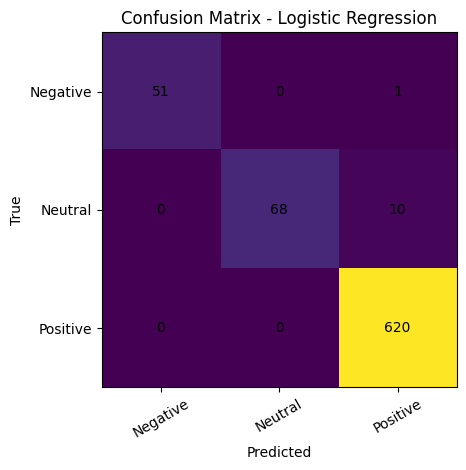

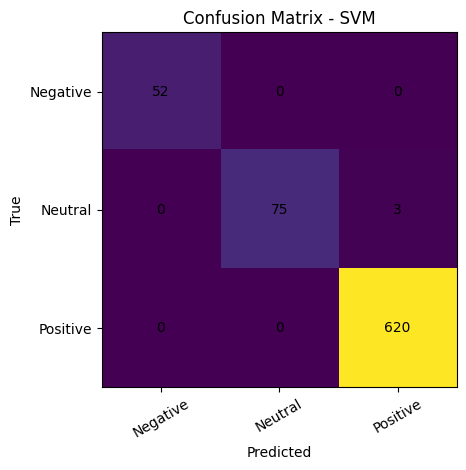

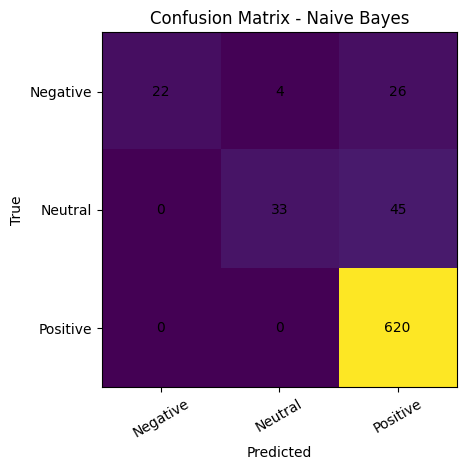

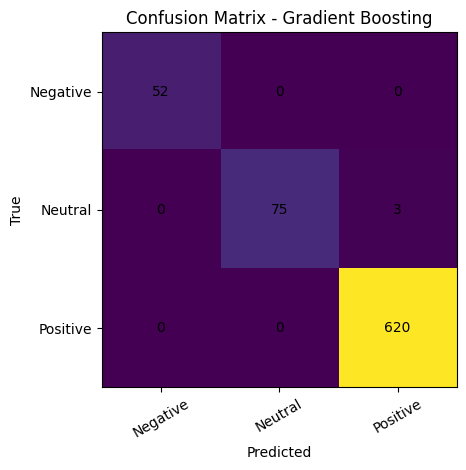

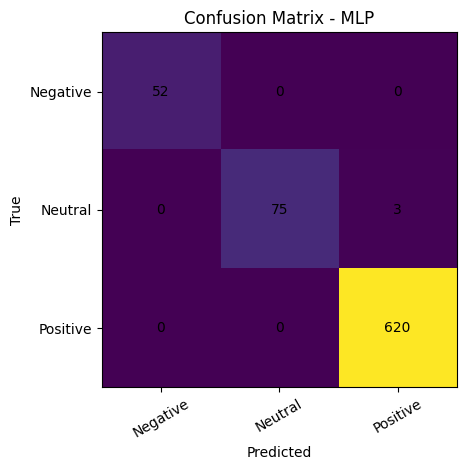

,model,accuracy,precision,recall,f1
0,LogisticRegression,0.985,0.986,0.985,0.985
1,SVM,0.996,0.996,0.996,0.996
2,NaiveBayes,0.900,0.904,0.900,0.883
3,GradientBoosting,0.996,0.996,0.996,0.996
4,MLP,0.996,0.996,0.996,0.996


In [50]:
# 13. Test ALL models (for comparison to choose best 2)

labels_order = ["Negative", "Neutral", "Positive"]

results = []

# ---------- Logistic Regression ----------
y_pred_lr = lr_pipeline.predict(X_test)
acc_lr, pr_lr, rc_lr, f1_lr, cm_lr = evaluate(y_test, y_pred_lr, labels=labels_order)

results.append({
    "model": "LogisticRegression",
    "accuracy": round(acc_lr, 3),
    "precision": round(pr_lr, 3),
    "recall": round(rc_lr, 3),
    "f1": round(f1_lr, 3)
})

save_confusion_phase2(cm_lr, labels_order, "Confusion Matrix - Logistic Regression", "cm_lr.png")


# ---------- SVM ----------
y_pred_svm = svm_pipeline.predict(X_test)
acc_svm, pr_svm, rc_svm, f1_svm, cm_svm = evaluate(y_test, y_pred_svm, labels=labels_order)

results.append({
    "model": "SVM",
    "accuracy": round(acc_svm, 3),
    "precision": round(pr_svm, 3),
    "recall": round(rc_svm, 3),
    "f1": round(f1_svm, 3)
})

save_confusion_phase2(cm_svm, labels_order, "Confusion Matrix - SVM", "cm_svm.png")


# ---------- Naive Bayes ----------
y_pred_nb = nb_pipeline.predict(X_test)
acc_nb, pr_nb, rc_nb, f1_nb, cm_nb = evaluate(y_test, y_pred_nb, labels=labels_order)

results.append({
    "model": "NaiveBayes",
    "accuracy": round(acc_nb, 3),
    "precision": round(pr_nb, 3),
    "recall": round(rc_nb, 3),
    "f1": round(f1_nb, 3)
})

save_confusion_phase2(cm_nb, labels_order, "Confusion Matrix - Naive Bayes", "cm_nb.png")


# ---------- Gradient Boosting ----------
X_test_gb = tfidf_gb.transform(X_test).toarray()
y_pred_gb = gb_model.predict(X_test_gb)

acc_gb, pr_gb, rc_gb, f1_gb, cm_gb = evaluate(y_test, y_pred_gb, labels=labels_order)

results.append({
    "model": "GradientBoosting",
    "accuracy": round(acc_gb, 3),
    "precision": round(pr_gb, 3),
    "recall": round(rc_gb, 3),
    "f1": round(f1_gb, 3)
})

save_confusion_phase2(cm_gb, labels_order, "Confusion Matrix - Gradient Boosting", "cm_gb.png")


# ---------- MLP ----------
y_pred_mlp = mlp_pipeline.predict(X_test)
acc_mlp, pr_mlp, rc_mlp, f1_mlp, cm_mlp = evaluate(y_test, y_pred_mlp, labels=labels_order)

results.append({
    "model": "MLP",
    "accuracy": round(acc_mlp, 3),
    "precision": round(pr_mlp, 3),
    "recall": round(rc_mlp, 3),
    "f1": round(f1_mlp, 3)
})

save_confusion_phase2(cm_mlp, labels_order, "Confusion Matrix - MLP", "cm_mlp.png")


# ---------- Display DataFrame ----------
results_df = pd.DataFrame(results)
display(results_df)

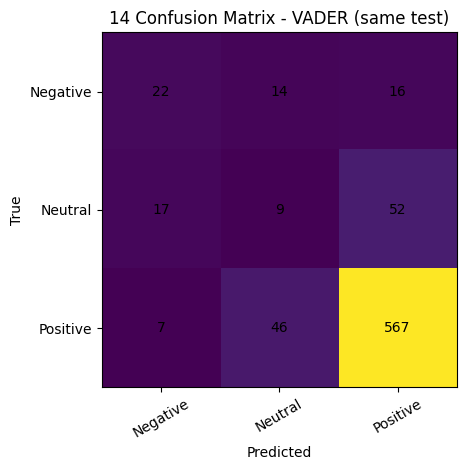

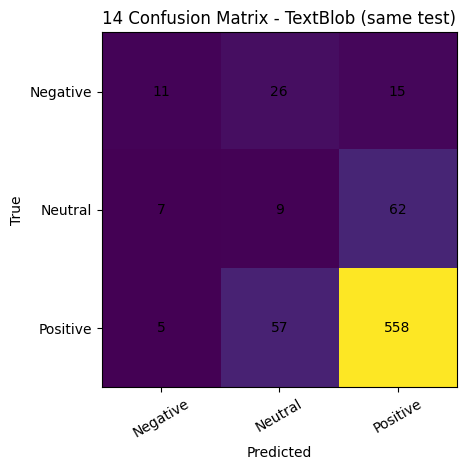

,model,accuracy,precision_w,recall_w,f1_w
2,LinearSVC,0.996000,0.996019,0.996000,0.995966
3,MLP,0.996000,0.996019,0.996000,0.995966
0,VADER,0.797333,0.784866,0.797333,0.790828
1,TextBlob,0.770667,0.769759,0.770667,0.766457


In [51]:
# 14.a. Prepare fair comparison data (apples-to-apples): exact same test set for Lexicon and ML models
# 14.b. Run Lexicon and ML models on same test rows and compare with same metrics
X_test_vader = X_test.apply(preprocess_for_vader)
X_test_textblob = X_test.apply(preprocess_for_textblob)

y_pred_vader_same = vader_predict(X_test_vader)
y_pred_textblob_same = textblob_predict(X_test_textblob)

acc_v, pr_v, rc_v, f1_v, cm_v = evaluate(y_test, y_pred_vader_same, labels=labels_order)
acc_tb, pr_tb, rc_tb, f1_tb, cm_tb = evaluate(y_test, y_pred_textblob_same, labels=labels_order)

same_test_comparison_df = pd.DataFrame([
    {"model": "VADER", "accuracy": acc_v, "precision_w": pr_v, "recall_w": rc_v, "f1_w": f1_v},
    {"model": "TextBlob", "accuracy": acc_tb, "precision_w": pr_tb, "recall_w": rc_tb, "f1_w": f1_tb},
    {"model": "LinearSVC", "accuracy": acc_svm, "precision_w": pr_svm, "recall_w": rc_svm, "f1_w": f1_svm},
    {"model": "MLP", "accuracy": acc_mlp, "precision_w": pr_mlp, "recall_w": rc_mlp, "f1_w": f1_mlp}
])

same_test_comparison_path = os.path.join(PHASE2_OUTPUT_DIR, "14_model_comparison_same_test.csv")
same_test_comparison_df.to_csv(same_test_comparison_path, index=False)

save_confusion_phase2(cm_v, labels_order, "14 Confusion Matrix - VADER (same test)", "14_cm_vader_same_test.png")
save_confusion_phase2(cm_tb, labels_order, "14 Confusion Matrix - TextBlob (same test)", "14_cm_textblob_same_test.png")

same_test_comparison_df.sort_values("accuracy", ascending=False)